In [5]:
"Up and running"

'Up and running'

In [6]:
# Third-party modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Custom modules
from misc import paths
from misc import style
from misc.logger import logger
logger.info('Importing modules completed')

4165540402.py INFO Importing modules completed


In [7]:
# Read the domtblout file
file_path = paths.INTACT / '2026-01-09' / 'hmmscan.domtblout'
df = pd.read_csv(file_path)

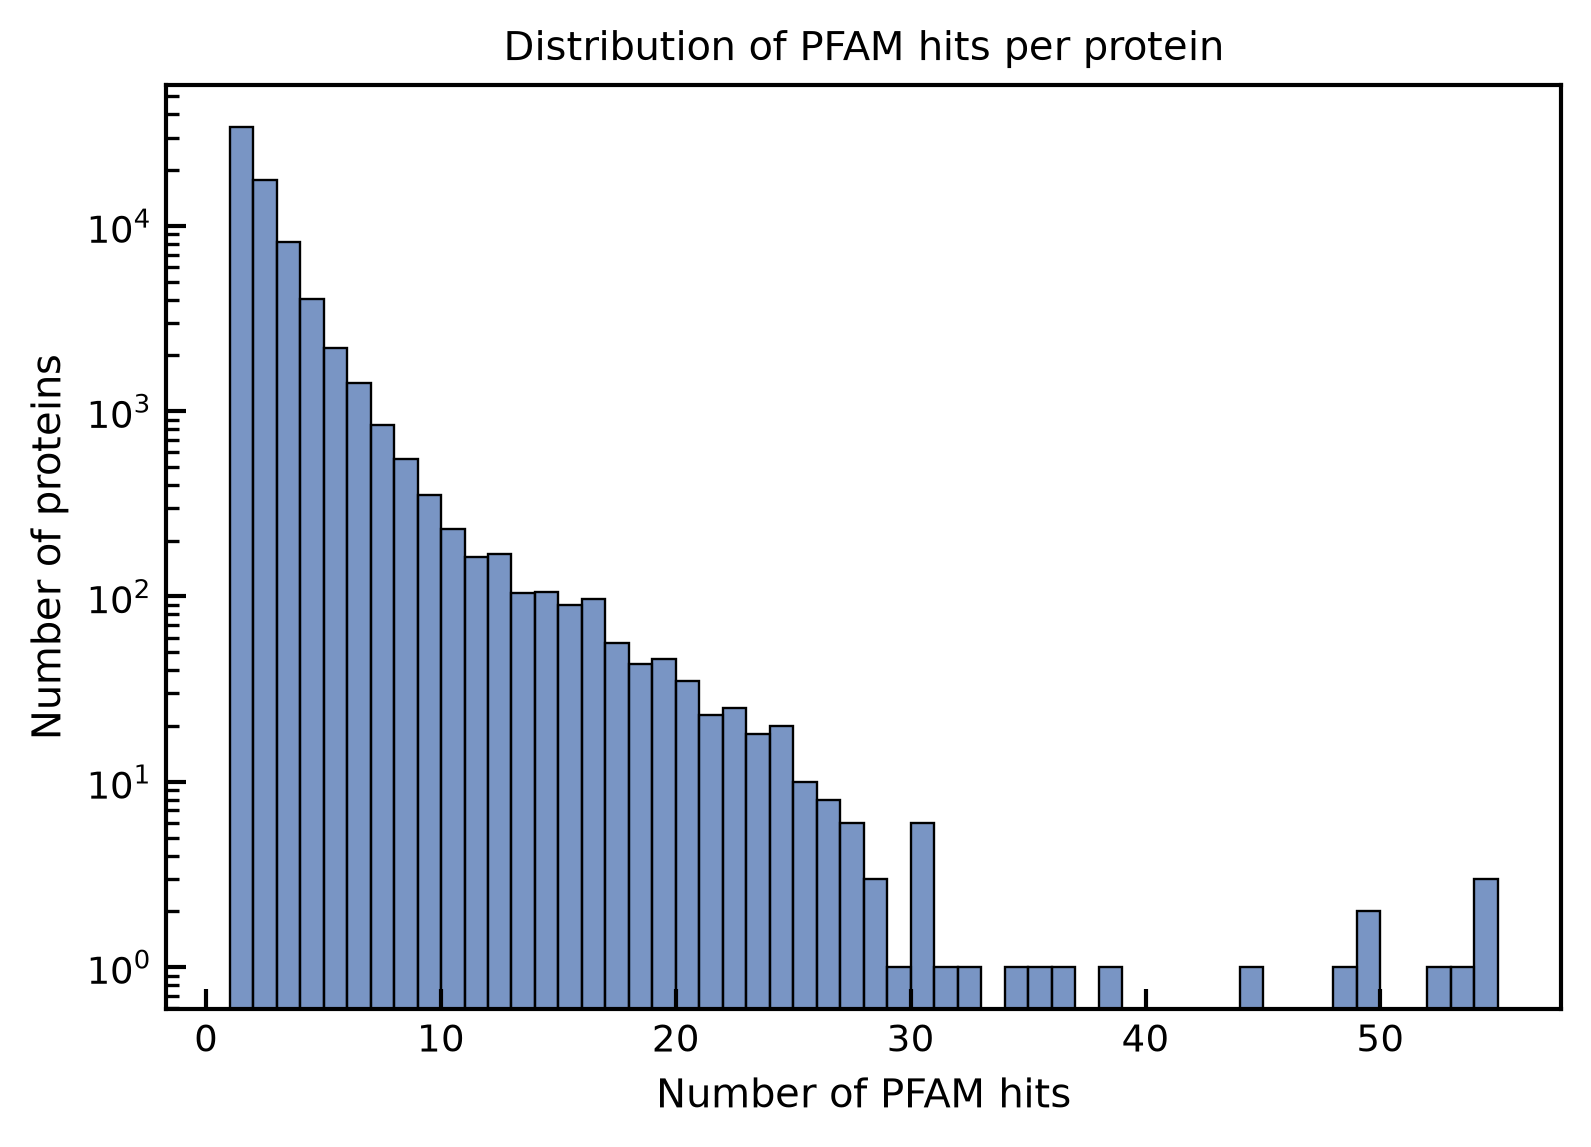

In [38]:
# Distribution of PFAM hits per protein
plt.figure(figsize=(6, 4))
n_domains = df.groupby('query_name').size()
ax = sns.histplot(n_domains, bins=n_domains.max()-1)
ax.set_yscale("log")
plt.title('Distribution of PFAM hits per protein')
plt.xlabel('Number of PFAM hits')
plt.ylabel('Number of proteins')
plt.show()

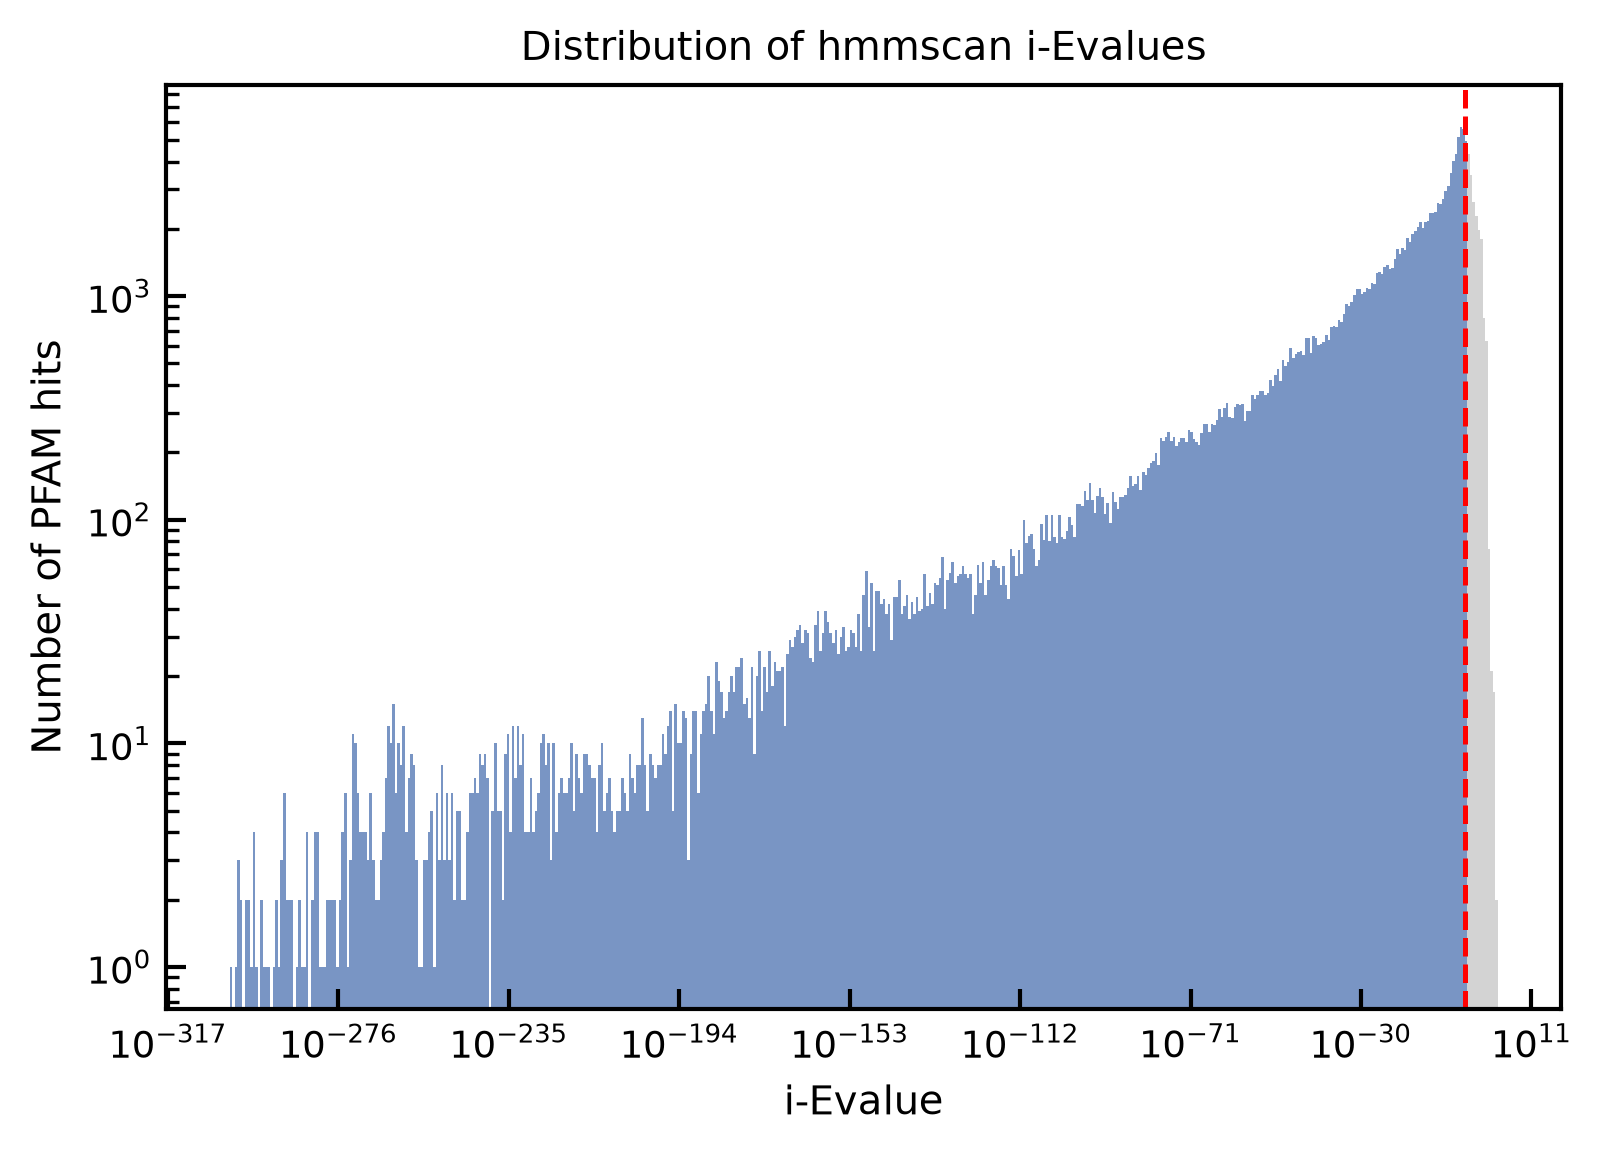

4061377007.py INFO Tallest bin is [5.67e-07, 2.32e-06] with 5711 hits.


In [40]:
# Distribution of hmmscan i-evalues

# Non-zero i-evalues
i_evalues = df['i_evalue'].values
i_evalues = np.asarray(i_evalues)
i_evalues = i_evalues[i_evalues > 0]

# Logarithmically spaced bins
bins = np.logspace(
    np.log10(i_evalues.min()),
    np.log10(i_evalues.max()),
    500 # number of bins
)

# Plot histogram of i-evalues
THRESHOLD = 1e-5
plt.figure(figsize=(6, 4))
ax = sns.histplot(i_evalues, bins=bins)
for patch, left, right in zip(ax.patches, bins[:-1], bins[1:]):
    if left >= THRESHOLD:
        patch.set_facecolor('lightgrey')
plt.axvline(THRESHOLD, color='red', linestyle='dashed')
plt.title("Distribution of hmmscan i-Evalues")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("i-Evalue")
plt.ylabel("Number of PFAM hits")
plt.show()

# Which bin has the most hits?
counts, bin_edges = np.histogram(e_values, bins=bins)
max_bin_index = np.argmax(counts)
max_bin_range = (bin_edges[max_bin_index], bin_edges[max_bin_index + 1])
logger.info(f"Tallest bin is [{max_bin_range[0]:.2e}, {max_bin_range[1]:.2e}] with {counts[max_bin_index]} hits.")